In [1]:
import numpy as np
import torch
import normflows as nf
from pid.models import CartesianProductFlow, GaussianFlow
from pid.optimizers import exact_gauss_tilde_pid, exact_gauss_thin_pid, flow_pid

from pid.utils import generate_randomBC
from torch.utils.data import TensorDataset, DataLoader

In [2]:
dm = 3  # Number of dimensions of M
dx = 10
dy = 10

hx, hy = generate_randomBC(dm, dx, dy)

sigm = np.eye(dm)
sigx_m = np.eye(dx)
sigy_m = np.eye(dy)
sigw = np.zeros((dx, dy))

# Covariance matrix construction for both unique or redundant
cov = np.block([[sigm, sigm @ hx.T, sigm @ hy.T],
                [hx @ sigm, hx @ sigm @ hx.T + sigx_m, hx @ sigm @ hy.T + sigw],
                [hy @ sigm, hy @ sigm @ hx.T + sigw.T, hy @ sigm @ hy.T + sigy_m]])

print(cov.shape)

ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"GPID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

(23, 23)
GPID: R: 4.201987379836478, U1: 0.7580941298568806, U2: 0.7919949150278658, S: 0.7767935428075674


In [3]:
n = 10000

mean = np.zeros(dm+dx+dy)
mxy = np.random.multivariate_normal(mean, cov, size=n)
cov = np.corrcoef(mxy.T)

ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"GPID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")
    # print(f'{samples} \n')

GPID: R: 4.224649197826967, U1: 0.7655232843799435, U2: 0.7667424992916994, S: 0.7876444576790274


In [4]:
mean = np.zeros(dm+dx+dy)
mxy = np.random.multivariate_normal(mean, cov, size=n)
m_data, x_data, y_data = np.hsplit(mxy, [dm, dm+dx])  # split m, x, y
print(m_data.shape, x_data.shape, y_data.shape)

x_data = x_data**3
y_data = np.cbrt(y_data)

(10000, 3) (10000, 10) (10000, 10)


In [5]:
new_mxy = np.hstack((m_data, x_data, y_data))
new_cov = np.corrcoef(new_mxy.T)
print(new_cov.shape)

ret = exact_gauss_tilde_pid(new_cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Tilde-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

ret = exact_gauss_thin_pid(new_cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Thin-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

(23, 23)
Tilde-PID: R: 2.2072317019469225, U1: 0.05382410463430709, U2: 1.3818129175711302, S: 1.1054679356283938
Thin-PID: R: 2.207231650748425, U1: 0.05382415583280453, U2: 1.3818129687696277, S: 1.1054678844298964


In [6]:
def standardize_data(data):
    data = np.nan_to_num((data - data.mean(axis=0)) / data.std(axis=0))
    data = np.clip(data, a_min=-10, a_max=10)
    return data

m_data_standardized = standardize_data(m_data)
x_data_standardized = standardize_data(x_data)
y_data_standardized = standardize_data(y_data)

standard_mxy = np.hstack((m_data_standardized, x_data_standardized, y_data_standardized))
standard_cov = np.corrcoef(standard_mxy.T)
print(new_cov.shape)

ret = exact_gauss_tilde_pid(new_cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Tilde-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

ret = exact_gauss_thin_pid(new_cov, dm, dx, dy)
imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
print(f"Thin-PID: R: {ri}, U1: {uix}, U2: {uiy}, S: {si}")

(23, 23)
Tilde-PID: R: 2.2072317019469225, U1: 0.05382410463430709, U2: 1.3818129175711302, S: 1.1054679356283938
Thin-PID: R: 2.207231650748425, U1: 0.05382415583280453, U2: 1.3818129687696277, S: 1.1054678844298964


In [7]:
dataset = TensorDataset(
    torch.from_numpy(x_data_standardized).float(),
    torch.from_numpy(y_data_standardized).float(),
    torch.from_numpy(m_data_standardized).float(),
)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

Using device: cuda


100%|██████████| 79/79 [00:09<00:00,  8.18it/s]


Train Epoch: 0/30 (0%)	Loss: 387.776211


100%|██████████| 79/79 [00:08<00:00,  9.22it/s]


Train Epoch: 1/30 (3%)	Loss: 115.239757


...

Train Epoch: 27/30 (90%)	Loss: 19.314829


100%|██████████| 79/79 [00:09<00:00,  8.56it/s]


Train Epoch: 28/30 (93%)	Loss: 18.681325


100%|██████████| 79/79 [00:08<00:00,  9.18it/s]

Train Epoch: 29/30 (97%)	Loss: 17.995948
Final Loss: 17.9959


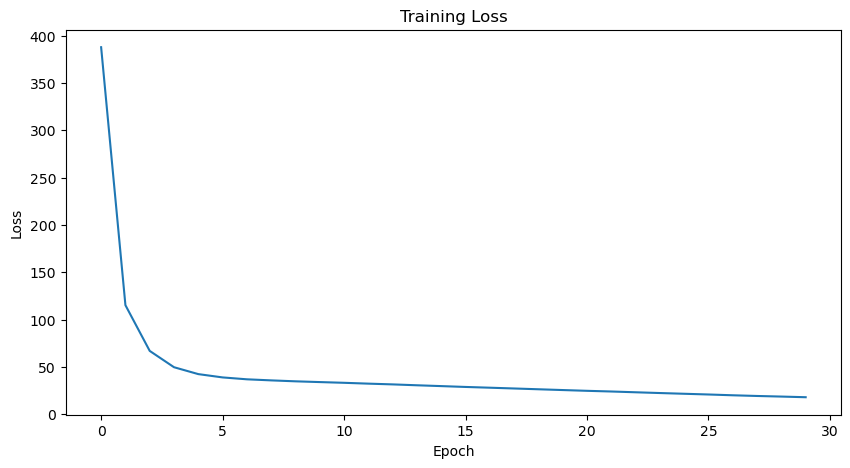

flow pid, normalized I_mxy, R: 2.9940307393431924, U1: 0.3495327386694873, U2: 0.9852749612512102, S: 0.8218659820420546


In [12]:
###### flow pid ######
enable_cuda=True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
print(f"Using device: {device}")

model = CartesianProductFlow(
    dm=dm,
    dx=dx,
    dy=dy,
    n_flows=32,
).to(device)

pid_flow = flow_pid.fit_flows(model, dataloader, n_epochs=30, lr=2e-4, device=device, verbose=True)
ret = flow_pid.fit_pid(pid_flow, dataloader, device=device, verbose=True)
norm = ret[7] + ret[5] + ret[6] + ret[8]
print(f"flow pid, normalized I_mxy, R: {ret[7]}, U1: {ret[5]}, U2: {ret[6]}, S: {ret[8]}")